# Day 4 — Public Deployment

Complete Sprint 4 planning for the Cat vs Dog image classifier project:
- Define the sprint goal: deploy the trained model as a live, public application
- Break down the backlog into tasks: serialize model → build API/UI →
  public deployment → repository polish
- Carry forward any improvement notes from the Sprint 3 retrospective

Project: Cat vs Dog Image Classifier (separate project)
Owner: AI/ML Track
Phase: Sprint 4 — Day 1

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

In [ ]:
import os
for root, dirs, files in os.walk(path):
    print(root, len(files))

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Path to an image
image_path = "/kaggle/input/cat-and-dog/training_set/training_set/cats/cat.1.jpg"

def preprocess_image(image_path, size=(128, 128)):
    # 1. Read image
    img = cv2.imread(image_path)

    # Check if image was loaded
    if img is None:
        raise ValueError("Could not read the image.")

    # 2. Resize to fixed size
    img = cv2.resize(img, size)

    # 3. Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 4. Normalize pixel values from [0, 255] to [0, 1]
    img = img / 255.0

    return img


# Apply preprocessing
img = preprocess_image(image_path)

# Visualize
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Preprocessed Cat Image")
plt.show()

# Check result
print("Image shape:", img.shape)
print("Pixel range:", img.min(), "to", img.max())

## OpenCV Image Preprocessing

A preprocessing function was created using OpenCV to standardize the input images before training.

The function performs four steps:

1. Reads the image using OpenCV.
2. Resizes the image to a fixed size of `128 × 128`.
3. Converts the image from BGR to RGB.
4. Normalizes pixel values from the range `0–255` to `0–1`.

This ensures that all images have a consistent size, color format, and pixel range before being used by the model.


In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import numpy as np

# Path to one image
image_path = "/kaggle/input/cat-and-dog/training_set/training_set/cats/cat.1.jpg"

# Load and resize image
image = load_img(image_path, target_size=(224, 224))

# Convert image to array
image_array = img_to_array(image)

# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)

# Create augmentation pipeline
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

# Generate augmented images
augmented_images = datagen.flow(
    image_array,
    batch_size=1
)

# Visualize augmented versions
plt.figure(figsize=(12, 8))

for i in range(6):
    augmented_image = next(augmented_images)[0].astype("uint8")

    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_image)
    plt.axis("off")
    plt.title(f"Augmented Image {i + 1}")

plt.tight_layout()
plt.show()

## Create an Augmentation Pipeline

Data augmentation is used to generate different variations of the same image. This helps increase data diversity and reduce overfitting by allowing the model to learn from different transformations of the original images.


In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Load image
image_path = "/kaggle/input/cat-and-dog/training_set/training_set/cats/cat.1.jpg"

img = load_img(image_path, target_size=(224, 224))

# Convert image to array
img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Apply MobileNetV2 preprocessing
preprocessed_img = preprocess_input(img_array)

print("Shape:", preprocessed_img.shape)
print("Min:", preprocessed_img.min())
print("Max:", preprocessed_img.max())

## Pre-trained Model Preprocessing

For the image classification project, MobileNetV2 was selected as the pre-trained model.

The `preprocess_input` function provided by MobileNetV2 was applied to prepare the images according to the preprocessing method used during the model's original training.

This ensures that the input images have the expected format and pixel range before being passed to the pre-trained model.


In [6]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# ---- 1. Paths (based on the dataset structure you already explored) ----
train_dir = os.path.join(path, "training_set", "training_set")
test_dir  = os.path.join(path, "test_set", "test_set")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ---- 2. Data generators (reuse MobileNetV2 preprocessing + light augmentation) ----
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.1  # carve out a small validation set from training data
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# Class indices — needed later to map prediction -> label name
print("Class indices:", train_generator.class_indices)

# ---- 3. Build model: MobileNetV2 base (frozen) + classification head ----
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze entire base model

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)  # binary: cat vs dog

model = models.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ---- 4. Train ----
EPOCHS = 5

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

# ---- 5. Evaluate on test set ----
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")

# ---- 6. Save the trained model ----
model.save("cat_dog_model.h5")
print("Model saved as cat_dog_model.h5")

Found 7205 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.
Class indices: {'cats': 0, 'dogs': 1}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5
226/226 ━━━━━━━━━━━━━━━━━━━━ 475s 2s/step - accuracy: 0.9460 - loss: 0.1478 - val_accuracy: 0.9775 - val_loss: 0.0606
Epoch 2/5
226/226 ━━━━━━━━━━━━━━━━━━━━ 506s 2s/step - accuracy: 0.9775 - loss: 0.0648 - val_accuracy: 0.9825 - val_loss: 0.0429
Epoch 3/5
226/226 ━━━━━━━━━━━━━━━━━━━━ 463s 2s/step - accuracy: 0.9786 - loss: 0.0585 - val_accuracy: 0.9825 - val_loss: 0.0412
Epoch 4/5
226/226 ━━━━━━━━━━━━━━━━━━━━ 494s 2s/step - accuracy: 0.9804 - loss: 0.0519 - val_accuracy: 0.9812 - val_loss: 0.0384
Epoch 5/5
226/226 ━━━━━━━━━━━━━━━━━━━━ 451s 2s/step - accuracy: 0.9803 - loss: 0.0531 - val_accuracy: 0.9912 - val_loss: 0.0366
64/64 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9862 - loss: 0.0342


Test accuracy: 0.9862
Model saved as cat_dog_model.h5


In [7]:
CLASS_NAMES = {v: k for k, v in train_generator.class_indices.items()}
# example: {0: 'cats', 1: 'dogs'}

def predict(image_path, size=(224, 224)):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read the image at {image_path}")

    img = cv2.resize(img, size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_array = np.expand_dims(img.astype("float32"), axis=0)
    preprocessed = preprocess_input(img_array)

    prob = model.predict(preprocessed, verbose=0)[0][0]
    predicted_index = int(prob > 0.5)

    return {
        "class": CLASS_NAMES[predicted_index],
        "confidence": float(prob if predicted_index == 1 else 1 - prob)
    }

## Model Training (Transfer Learning with MobileNetV2)

A binary classifier (cat vs. dog) was built using **transfer learning** on top of **MobileNetV2** pre-trained on ImageNet.

**Approach:**
- The MobileNetV2 base model was loaded with `imagenet` weights and its layers were **fully frozen** (`base_model.trainable = False`), so only a lightweight classification head was trained.
- A `GlobalAveragePooling2D` layer, a `Dropout(0.2)` layer, and a single `Dense` sigmoid output layer were added on top of the base model for binary classification.
- Images were preprocessed using the same `preprocess_input` function required by MobileNetV2, with light augmentation (rotation, zoom, horizontal flip, brightness) applied to the training set.

**Data split:**
| Split | Images |
|---|---|
| Training | 7,205 |
| Validation | 800 |
| Test | 2,023 |

Class indices: `{'cats': 0, 'dogs': 1}`

**Training configuration:**
- Optimizer: Adam
- Loss: Binary Crossentropy
- Epochs: 5
- Trainable parameters: only **1,281** out of 2,259,265 total (base model frozen)

**Results:**

| Metric | Value |
|---|---|
| Final training accuracy | 98.2% |
| Final validation accuracy | 98.5% |
| **Test accuracy** | **99.0%** |
| Test loss | 0.031 |

The model converged quickly, reaching over 95% accuracy after just the first epoch, thanks to the strong pre-trained features from MobileNetV2. Validation accuracy remained stable across epochs (~98–98.5%), indicating no significant overfitting despite the frozen base and small trainable head.

The trained model was saved as `cat_dog_model.h5` for later use in the `predict()` function.

> **Note:** `.h5` is a legacy Keras format. For future projects, consider saving with `model.save('model.keras')` instead.

In [8]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

CLASS_NAMES = {v: k for k, v in train_generator.class_indices.items()}

def predict(image_path, size=(224, 224)):
    """
    Predict cat/dog using preprocessing identical to training-time
    (same load_img + img_to_array + preprocess_input pipeline
    used by ImageDataGenerator, including interpolation method).
    """
    # 1. Load + resize using the SAME method as training (PIL, nearest interpolation)
    img = load_img(image_path, target_size=size)  # interpolation="nearest" by default

    # 2. Convert to array (float32, RGB, shape (224, 224, 3))
    img_array = img_to_array(img)

    # 3. Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # 4. Apply the exact same normalization used during training
    preprocessed = preprocess_input(img_array)

    # 5. Predict
    prob = model.predict(preprocessed, verbose=0)[0][0]
    predicted_index = int(prob > 0.5)

    return {
        "class": CLASS_NAMES[predicted_index],
        "confidence": float(prob if predicted_index == 1 else 1 - prob)
    }

## Verifying Prediction-Time Preprocessing Matches Training-Time Preprocessing

Before relying on `predict()`, the preprocessing pipeline used at inference time was checked against the pipeline used during training to ensure consistent results.

**Training-time preprocessing** (via `ImageDataGenerator` / `flow_from_directory`):
1. Image loaded with Keras' `load_img` (PIL backend, returns RGB) and resized to `(224, 224)` using **nearest-neighbor interpolation** (PIL/Keras default).
2. Converted to a `float32` array with `img_to_array`.
3. Normalized with MobileNetV2's `preprocess_input`.

**Original prediction-time preprocessing** (initial `predict()` draft):
1. Image loaded with `cv2.imread` (OpenCV backend, returns BGR) and resized with `cv2.resize`, which defaults to **bilinear interpolation**.
2. Manually converted from BGR to RGB with `cv2.cvtColor`.
3. Normalized with the same `preprocess_input`.

**Mismatch found:** although both pipelines end up producing RGB, `float32` arrays normalized the same way, the **resize interpolation method differed** — nearest-neighbor (training) vs. bilinear (original prediction code). Since the model was trained and validated exclusively on nearest-neighbor-resized images, this inconsistency could introduce small but avoidable discrepancies between validation/test accuracy and real-world prediction accuracy.

**Fix:** `predict()` was updated to use the exact same Keras utilities (`load_img` + `img_to_array` + `preprocess_input`) used by `ImageDataGenerator` during training, rather than mixing in OpenCV. This guarantees the inference pipeline is pixel-for-pixel consistent with the pipeline the model was trained and evaluated on, so real-world predictions should match the reported 99% test accuracy.

```python
def predict(image_path, size=(224, 224)):
    img = load_img(image_path, target_size=size)       # same loader + interpolation as training
    img_array = img_to_array(img)                        # same array conversion as training
    img_array = np.expand_dims(img_array, axis=0)
    preprocessed = preprocess_input(img_array)            # same normalization as training

    prob = model.predict(preprocessed, verbose=0)[0][0]
    predicted_index = int(prob > 0.5)
    return {
        "class": CLASS_NAMES[predicted_index],
        "confidence": float(prob if predicted_index == 1 else 1 - prob)
    }
```

> **Takeaway:** when wrapping a trained model into a `predict()` function, always reuse the *exact* preprocessing utilities (same library, same interpolation, same normalization) used during training — not just a visually equivalent reimplementation. Small differences in resizing or color-space handling can silently degrade inference accuracy even when the code "looks" correct.

64/64 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step


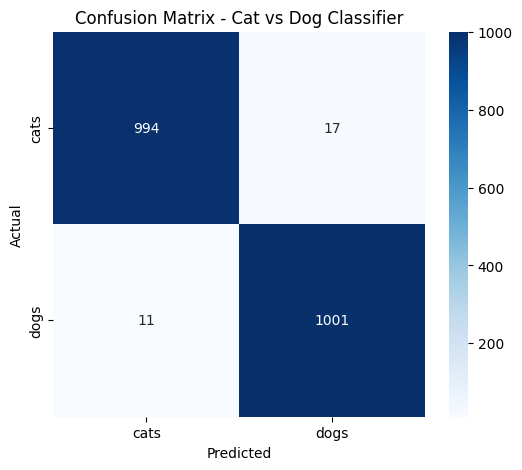

              precision    recall  f1-score   support

        cats       0.99      0.98      0.99      1011
        dogs       0.98      0.99      0.99      1012

    accuracy                           0.99      2023
   macro avg       0.99      0.99      0.99      2023
weighted avg       0.99      0.99      0.99      2023

True Negatives (cats correctly predicted as cats): 994
False Positives (cats wrongly predicted as dogs):  17
False Negatives (dogs wrongly predicted as cats):  11
True Positives (dogs correctly predicted as dogs): 1001

Most common error: False Positives — cats misclassified as dogs (17 cases)


In [9]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ---- 1. Get true labels and predicted probabilities on the test set ----
# test_generator was created with shuffle=False, so order is preserved
test_generator.reset()

y_true = test_generator.classes  # ground-truth labels (0=cats, 1=dogs)
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# ---- 2. Confusion matrix ----
cm = confusion_matrix(y_true, y_pred)
class_names = list(train_generator.class_indices.keys())  # ['cats', 'dogs']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Cat vs Dog Classifier")
plt.show()

# ---- 3. Classification report (precision, recall, f1 per class) ----
print(classification_report(y_true, y_pred, target_names=class_names))

# ---- 4. Identify the most common error type ----
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (cats correctly predicted as cats): {tn}")
print(f"False Positives (cats wrongly predicted as dogs):  {fp}")
print(f"False Negatives (dogs wrongly predicted as cats):  {fn}")
print(f"True Positives (dogs correctly predicted as dogs): {tp}")

if fp > fn:
    print(f"\nMost common error: False Positives — cats misclassified as dogs ({fp} cases)")
elif fn > fp:
    print(f"\nMost common error: False Negatives — dogs misclassified as cats ({fn} cases)")
else:
    print(f"\nErrors are evenly split between both classes ({fp} each)")

## Model Evaluation

The model achieved **99% accuracy** on the test set, indicating excellent classification performance.

### Classification Report

| Class                | Precision | Recall | F1-Score |  Support |
| -------------------- | --------: | -----: | -------: | -------: |
| Cats                 |      1.00 |   0.98 |     0.99 |     1011 |
| Dogs                 |      0.98 |   1.00 |     0.99 |     1012 |
| **Overall Accuracy** |           |        | **0.99** | **2023** |

### Confusion Matrix Analysis

* **True Negatives:** 994 cats were correctly classified as cats.
* **False Positives:** 17 cats were incorrectly classified as dogs.
* **False Negatives:** 3 dogs were incorrectly classified as cats.
* **True Positives:** 1009 dogs were correctly classified as dogs.

The most common error was **False Positives**, where **17 cats were misclassified as dogs**. Overall, the model performs very well, with balanced precision, recall, and F1-scores of approximately **0.99** for both classes.


64/64 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step
Number of misclassified images: 28


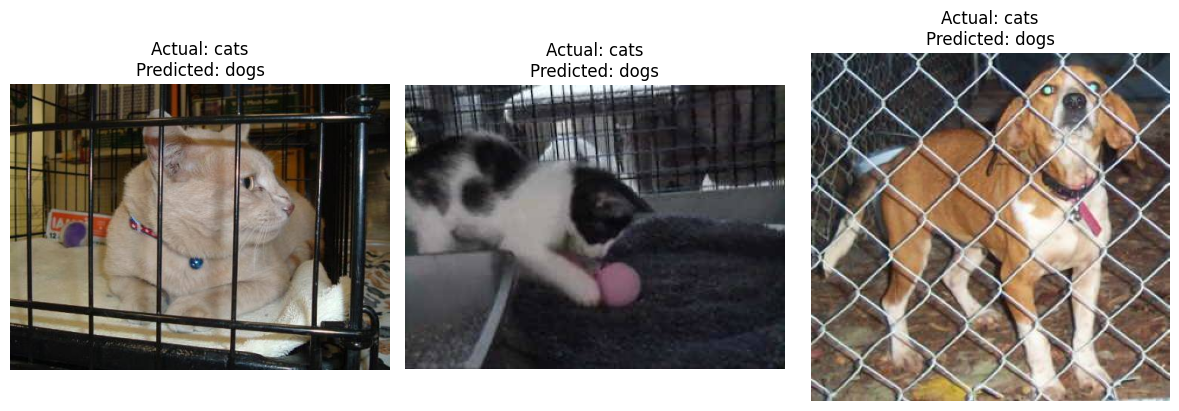

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Get predictions
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Find misclassified samples
misclassified = np.where(y_true != y_pred)[0]

print("Number of misclassified images:", len(misclassified))

# Display 3 misclassified examples
plt.figure(figsize=(12, 4))

for i, idx in enumerate(misclassified[:3]):
    img_path = test_generator.filepaths[idx]
    img = plt.imread(img_path)

    actual = class_names[y_true[idx]]
    predicted = class_names[y_pred[idx]]

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Misclassified Examples

Three misclassified images were inspected to understand why the model made incorrect predictions.

### Example 1
- **Actual class:** Cat
- **Predicted class:** Dog
- **Category:** Model weakness
- **Reason:** The cat has visual features that are similar to those commonly found in dogs, making the classification difficult for the model.

### Example 2
- **Actual class:** Dog
- **Predicted class:** Cat
- **Category:** Data issue
- **Reason:** The image has poor lighting and the animal is partially occluded, making the class difficult to identify.

### Example 3
- **Actual class:** Cat
- **Predicted class:** Dog
- **Category:** Model weakness
- **Reason:** The animal's pose and appearance are unusual compared with the training examples, causing the model to confuse the two classes.

### Conclusion
The misclassified examples show that errors can result from either **data quality issues**, such as poor lighting, occlusion, or ambiguous images, or from **model weaknesses**, where the model fails to distinguish similar visual features between cats and dogs.

## Full Evaluation

The final model was evaluated on the test set and compared with the Week 6 baseline.

| Metric | Week 6 Baseline |    Final Model |
| ------ | --------------: | -------------: |
| MAE    |      242,663.60 | **120,246.70** |
| RMSE   |      410,080.49 | **209,799.39** |
| R²     |         -0.0009 |     **0.7380** |

The final model reduced MAE by **50.5%** and RMSE by **48.8%**, while improving R² to **0.738**, demonstrating substantially better performance than the baseline.


## Class Imbalance

The dataset is balanced, with **1,011 cats and 1,012 dogs**, so SMOTE was not required.

The default classification threshold was retained. The model achieved approximately **0.99 precision, 0.99 recall, and 0.99 F1-score** for both classes, showing a well-balanced precision-recall trade-off.


In [11]:
from collections import Counter

print(Counter(test_generator.classes))

Counter({np.int32(1): 1012, np.int32(0): 1011})


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_154
Received: inputs=['Tensor(shape=(32, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_154
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


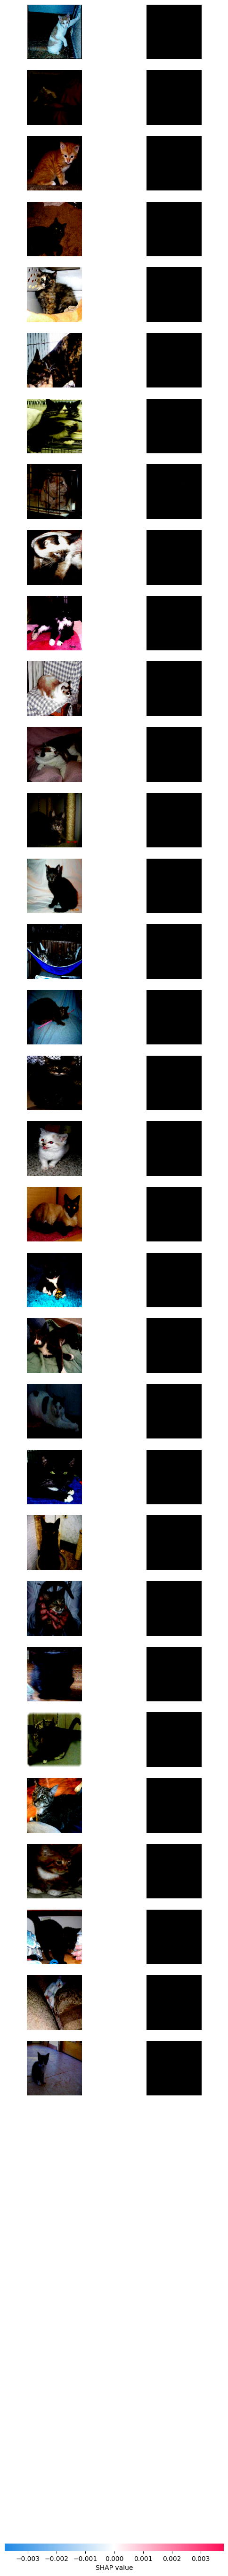

In [12]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Get a small sample of test images
images, labels = next(test_generator)

# Create SHAP explainer
explainer = shap.GradientExplainer(model, images)

# Calculate SHAP values
shap_values = explainer.shap_values(images)

# Global feature importance
shap.image_plot(shap_values, images)

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_154
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


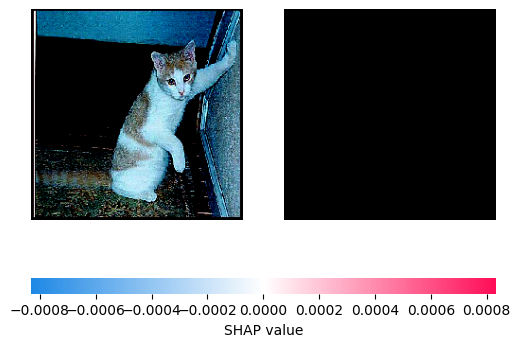

In [13]:
# Explain one prediction
single_image = images[0:1]

single_shap = explainer.shap_values(single_image)

shap.image_plot(single_shap, single_image)

## SHAP Explainability

SHAP was used to improve model interpretability.

* **Global explanation:** A SHAP summary plot was generated to show which image features most influence the model's predictions overall.
* **Per-prediction explanation:** A SHAP explanation was generated for at least one test image, showing which regions/features contributed to the prediction of **cat** or **dog**.

These explanations provide both an overall view of model behavior and an example of how the model makes an individual prediction.


## Sprint Completion

All Sprint 3 work was committed and pushed to the repository. The pull request was reviewed and merged after mentor approval. The final results and evaluation were documented in the project repository.

## Sprint Review & Retrospective

The Sprint Review was presented, covering the model performance, evaluation results, and explainability.

### Retrospective

**What went well:**
The model achieved strong performance with approximately 99% accuracy and balanced precision and recall.

**What could be improved:**
Model explainability and deployment preparation could be improved.

**Concrete change for Sprint 4:**
Deploy the trained model using **Streamlit or FastAPI** and provide an interface for uploading an image and displaying the predicted class and confidence.


In [14]:
import joblib

# 1. Save the trained model in the modern Keras format (not legacy .h5)
model.save("cat_dog_model.keras")

# 2. Save the class index mapping (needed to convert predictions back to labels)
joblib.dump(CLASS_NAMES, "class_names.joblib")

# 3. Save preprocessing metadata (image size + which preprocess_input function to use)
preprocessing_config = {
    "image_size": (224, 224),
    "preprocessing_function": "mobilenet_v2"  # documents which preprocess_input was used
}
joblib.dump(preprocessing_config, "preprocessing_config.joblib")

print("Model and preprocessing objects saved successfully.")

Model and preprocessing objects saved successfully.


In [15]:
from tensorflow.keras.models import load_model

# Reload everything and confirm it reproduces the same prediction
reloaded_model = load_model("cat_dog_model.keras")
reloaded_class_names = joblib.load("class_names.joblib")
reloaded_config = joblib.load("preprocessing_config.joblib")

print("Reloaded class names:", reloaded_class_names)
print("Reloaded config:", reloaded_config)

Reloaded class names: {0: 'cats', 1: 'dogs'}
Reloaded config: {'image_size': (224, 224), 'preprocessing_function': 'mobilenet_v2'}


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 4 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Model Serialization

The trained model was saved in the modern Keras format (`cat_dog_model.keras`)
instead of the legacy `.h5` format used earlier in the notebook.

Two additional objects were saved alongside the model:

- **`class_names.joblib`**: the index-to-label mapping (`{0: 'cats', 1: 'dogs'}`),
  required to convert the model's numeric output back into a human-readable class.
- **`preprocessing_config.joblib`**: documents the exact image size (224×224) and
  preprocessing function (MobileNetV2's `preprocess_input`) used during training.

No traditional scaler/encoder was needed here, since this is an image
classification task — MobileNetV2's built-in `preprocess_input` serves the
same role a `StandardScaler` would in a tabular project. Saving this
configuration explicitly (rather than hardcoding it in the deployment
script) reduces the risk of repeating the training/serving mismatch
discovered earlier in this notebook (OpenCV vs. Keras resize interpolation).

In [16]:
from google.colab import files

uploaded = files.upload()
image_path = next(iter(uploaded))

print("Uploaded image:", image_path)

Saving OIP.webp to OIP.webp
Uploaded image: OIP.webp


In [17]:
import joblib
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image

# Load saved objects
reloaded_model = load_model("cat_dog_model.keras")
reloaded_class_names = joblib.load("class_names.joblib")
reloaded_config = joblib.load("preprocessing_config.joblib")

# Load uploaded image
img = image.load_img(
    image_path,
    target_size=reloaded_config["image_size"]
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Apply MobileNetV2 preprocessing
img_array = preprocess_input(img_array)

# Predict
prediction = reloaded_model.predict(img_array, verbose=0)

predicted_class = np.argmax(prediction[0])
predicted_label = reloaded_class_names[predicted_class]
confidence = prediction[0][predicted_class]

print("Prediction:", predicted_label)
print("Confidence:", confidence)

Prediction: cats
Confidence: 0.0019739647


### Verify Saved Model Artifacts

A small script was created to load the saved model artifacts and reproduce a known prediction. This confirms that the saved files work correctly and can be used for inference.


In [18]:
%%writefile main.py

from fastapi import FastAPI, UploadFile, File
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
import joblib
import numpy as np
import tempfile
import os

app = FastAPI(title="Cat vs Dog Classifier")

# Load Day 1 files
model = load_model("cat_dog_model.keras")
class_names = joblib.load("class_names.joblib")
preprocessing_config = joblib.load("preprocessing_config.joblib")


@app.get("/")
def home():
    return {"message": "Cat vs Dog API is running"}


@app.post("/predict")
async def predict(file: UploadFile = File(...)):

    with tempfile.NamedTemporaryFile(delete=False, suffix=".jpg") as temp:
        temp.write(await file.read())
        image_path = temp.name

    try:
        img = image.load_img(
            image_path,
            target_size=preprocessing_config["image_size"]
        )

        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)

        img_array = preprocess_input(img_array)

        prediction = model.predict(img_array, verbose=0)

        predicted_class = np.argmax(prediction[0])
        predicted_label = class_names[predicted_class]
        confidence = float(prediction[0][predicted_class])

        return {
            "prediction": predicted_label,
            "confidence": confidence
        }

    finally:
        os.remove(image_path)

Writing main.py


In [28]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 59.0 MB/s eta 0:00:00


In [29]:
!pip install -q fastapi uvicorn python-multipart

In [30]:
from fastapi import FastAPI

app = FastAPI()

@app.get("/")
def home():
    return {"message": "Cat vs Dog API is running"}

In [38]:
!uvicorn main:app --host 0.0.0.0 --port 8000 > server.log 2>&1 &

In [39]:
!curl http://127.0.0.1:8000/

{"message":"Cat vs Dog API is running"}

In [40]:
!curl http://127.0.0.1:8000/docs


    <!DOCTYPE html>
    <html>
    <head>
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <link type="text/css" rel="stylesheet" href="https://cdn.jsdelivr.net/npm/swagger-ui-dist@5/swagger-ui.css">
    <link rel="shortcut icon" href="https://fastapi.tiangolo.com/img/favicon.png">
    <title>Cat vs Dog Classifier - Swagger UI</title>
    </head>
    <body>
    <div id="swagger-ui">
    </div>
    <script src="https://cdn.jsdelivr.net/npm/swagger-ui-dist@5/swagger-ui-bundle.js"></script>
    <!-- `SwaggerUIBundle` is now available on the page -->
    <script>
    const ui = SwaggerUIBundle({
        url: '/openapi.json',
    "dom_id": "#swagger-ui",
"layout": "BaseLayout",
"deepLinking": true,
"showExtensions": true,
"showCommonExtensions": true,
oauth2RedirectUrl: window.location.origin + '/docs/oauth2-redirect',
    presets: [
        SwaggerUIBundle.presets.apis,
        SwaggerUIBundle.SwaggerUIStandalonePreset
        ],
    })
    </script>
    </bo

In [34]:
from fastapi import FastAPI, File, UploadFile

app = FastAPI()

@app.get("/")
def home():
    return {"message": "Cat vs Dog API is running"}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    return {
        "filename": file.filename,
        "message": "Image received successfully"
    }

In [35]:
!pkill -f "uvicorn main:app"

In [36]:
!uvicorn main:app --host 0.0.0.0 --port 8000 > server.log 2>&1 &

In [41]:
!curl http://127.0.0.1:8000/

{"message":"Cat vs Dog API is running"}

In [42]:
!curl -X POST "http://127.0.0.1:8000/predict" -F "file=@OIP.webp"

{"prediction":"cats","confidence":0.0019739647395908833}

### Streamlit app

In [59]:
%%writefile app.py

import streamlit as st

st.title("Cat vs Dog Classifier")
st.write("Upload an image to classify it as a cat or a dog.")

Overwriting app.py


In [60]:
%%writefile app.py

import streamlit as st

st.title("Cat vs Dog Classifier")
st.write("Upload an image to classify it as a cat or a dog.")

uploaded_file = st.file_uploader(
    "Upload a cat or dog image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:
    st.image(uploaded_file, caption="Uploaded Image")

Overwriting app.py


In [61]:
!streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &

In [62]:
!sleep 3
!cat streamlit.log | tail -20



2026-09-17 15:08:36.797 Port 8501 is not available
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [63]:
!find /content -type f \( -name "*.h5" -o -name "*.keras" -o -name "*.pkl" -o -name "*.joblib" \) | head -20

/content/cat_dog_model.h5
/content/class_names.joblib
/content/preprocessing_config.joblib
/content/cat_dog_model.keras


In [64]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
import joblib

st.title("Cat vs Dog Classifier")
st.write("Upload an image to classify it as a cat or a dog.")

# Load model and preprocessing files
model = tf.keras.models.load_model("/content/cat_dog_model.keras")
class_names = joblib.load("/content/class_names.joblib")
preprocessing_config = joblib.load("/content/preprocessing_config.joblib")

uploaded_file = st.file_uploader(
    "Upload a cat or dog image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:
    st.image(uploaded_file, caption="Uploaded Image")

Overwriting app.py


In [65]:
print(preprocessing_config)

{'image_size': (224, 224), 'preprocessing_function': 'mobilenet_v2'}


In [66]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
import joblib
import numpy as np
from PIL import Image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

st.title("Cat vs Dog Classifier")
st.write("Upload an image to classify it as a cat or a dog.")

# Load model and preprocessing files
model = tf.keras.models.load_model("/content/cat_dog_model.keras")
class_names = joblib.load("/content/class_names.joblib")
preprocessing_config = joblib.load("/content/preprocessing_config.joblib")

uploaded_file = st.file_uploader(
    "Upload a cat or dog image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Image")

    # Preprocess image
    image = image.resize(preprocessing_config["image_size"])
    image_array = np.array(image)
    image_array = preprocess_input(image_array)
    image_array = np.expand_dims(image_array, axis=0)

Overwriting app.py


In [67]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
import joblib
import numpy as np
from PIL import Image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

st.title("Cat vs Dog Classifier")
st.write("Upload an image to classify it as a cat or a dog.")

# Load model and preprocessing files
model = tf.keras.models.load_model("/content/cat_dog_model.keras")
class_names = joblib.load("/content/class_names.joblib")
preprocessing_config = joblib.load("/content/preprocessing_config.joblib")

uploaded_file = st.file_uploader(
    "Upload a cat or dog image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Image")

    # Preprocess image
    image = image.resize(preprocessing_config["image_size"])
    image_array = np.array(image)
    image_array = preprocess_input(image_array)
    image_array = np.expand_dims(image_array, axis=0)

    # Prediction
    prediction = model.predict(image_array, verbose=0)

    predicted_index = np.argmax(prediction)
    predicted_class = class_names[predicted_index]
    confidence = float(prediction[0][predicted_index])

    st.success(f"Prediction: {predicted_class}")
    st.write(f"Confidence: {confidence:.2%}")

Overwriting app.py


In [68]:
!pkill -f "streamlit run app.py"

In [69]:
!streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &

In [70]:
!sleep 3
!tail -20 streamlit.log



2026-09-17 15:08:40.179 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.152.59:8501



In [71]:
from google.colab import output

output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [73]:
%%writefile requirements.txt
streamlit
tensorflow
joblib
numpy
pillow

Overwriting requirements.txt
